# Lab 1 model revisited

Let's reload the profiles from lab 1 and see what they say about the Fermi energy.

In [11]:
import mesa_reader as mr
import numpy as np

In [12]:
model1 = mr.MesaData("lab1/profile1.data")
model2 = mr.MesaData("lab1/profile2.data")

In [13]:
r1 = 10.0**model1.logR
m1 = model1.mass
rho1 = 10.0**model1.logRho
T1 = 10.0**model1.logT

In [14]:
r2 = 10.0**model2.logR
m2 = model2.mass
rho2 = 10.0**model2.logRho
T2 = 10.0**model2.logT

## Finding the Fermi energy in our model

We can compute the Fermi energy, by getting the degeneracy parameter:

$$\eta = \mathcal{E}_F/(kT) = (\mu - m_e c^2)/(kT)$$

So 

$$\mathcal{E}_F = \eta k T$$

Note that this is the kinetic energy, since the rest mass was subtracted off.
This is the energy that is available to overcome the energy difference in
nuclei and electron-capture.

We can compute the Fermi energy from the Fermi-Dirac distribution:

$$n_e = \frac{\rho Y_e}{m_u} = \frac{8\pi}{h^3} \int_0^\infty \frac{p^2}{e^{\mathcal{E}(p)/k_B T - \eta} + 1} dp$$

with 

$$\mathcal{E}(p) = m_e c^2 \left [ \sqrt{1 + \left ( \frac{p}{m_e c} \right )^2 } - 1 \right ]$$

Given the density and $Y_e$, we can root-find on this to get $\eta$

In [15]:
import pynucastro as pyna
from pynucastro import mesa_utils

In [16]:
eos = pyna.eos.ElectronEOS()

In [17]:
kB = pyna.constants.constants.k
erg2MeV = pyna.constants.constants.erg2MeV

We'll work with the late time model

In [18]:
mesa_zones = mesa_utils.get_all_data(model2)

Note: this is slow cause it's doing the integration directly.

In [19]:
E_fermi = np.zeros_like(rho2)
for i, v in mesa_zones.items():
    rho, T, comp = v
    es, ps = eos.pe_state(rho, T, comp, compute_derivs=False)
    eta = es.eta
    E_fermi[i] = eta * kB * T

E_fermi *= erg2MeV

In [21]:
import matplotlib.pyplot as plt

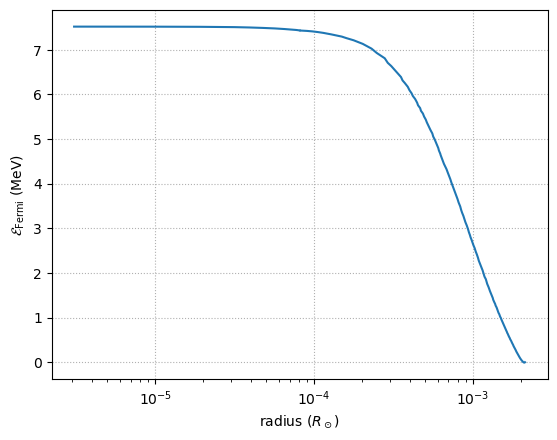

In [22]:
fig, ax = plt.subplots()
ax.semilogx(r2, E_fermi)
ax.set_xlabel(r"radius ($R_\odot$)")
ax.set_ylabel(r"$\mathcal{E}_\mathrm{Fermi}$ (MeV)")
ax.grid(ls=":")

Notice that the Fermi energy is highest at the core of the WD, as expected.
And it is > 7 MeV, which is large comparable to the typical binding energy
/ nucleon in a nucleus.

## Correspondence with Urca shell

Let's overlay $X({}^{23}\mathrm{Na})$ and $X({}^{23}\mathrm{Ne})$.  Their mass-fractions are small, so we'll scale by the maximum to make them $\mathcal{O}(1)$ in the plot.

In [24]:
X_na23 = model2.na23
X_ne23 = model2.ne23
scale = max(X_na23.max(), X_ne23.max())

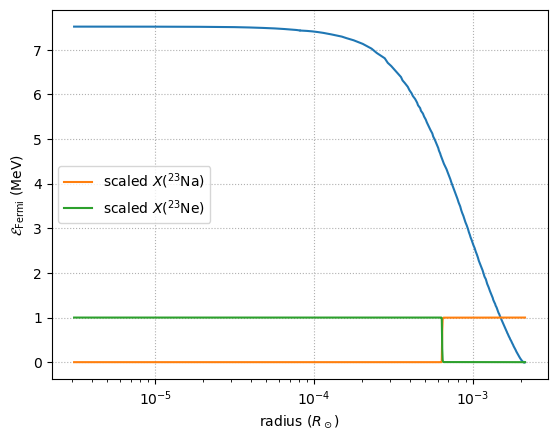

In [25]:
ax.semilogx(r2, X_na23/scale, label=r"scaled $X({}^{23}\mathrm{Na})$")
ax.semilogx(r2, X_ne23/scale, label=r"scaled $X({}^{23}\mathrm{Ne})$")
ax.legend()
fig

Now let's compute the Q-value of the reaction to figure out what Fermi energy should be the threshold

In [26]:
Na23 = pyna.Nucleus("na23")
Ne23 = pyna.Nucleus("ne23")
Q = Ne23.mass - Na23.mass
Q

4.375803499999165

Note that these are the atomic masses, from Nubase, so they include the electron mass (we'll neglect the atomic binding energy)

In [27]:
E_thresh = Q

Now, where is this in our model?

In [28]:
idx = np.where(E_fermi > E_thresh)[0][0]
idx

np.int64(373)

we'll draw a vertical line indicating where $\mathcal{E}_\mathrm{Fermi} \sim Q$

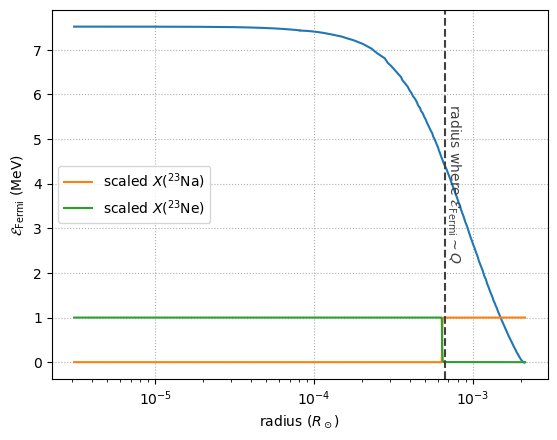

In [29]:
ax.axvline(r2[idx], color="0.25", ls="--")
ax.text(r2[idx], 4, r"radius where $\mathcal{E}_\mathrm{Fermi} \sim Q$",
        rotation=270, color="0.25", verticalalignment="center")
fig

Notice that the location of $\mathcal{E}_\mathrm{Fermi} = Q$ corresponds to the radius where the $A=23$ Urca pair nuclei switch abundances.

```{important}
This is approximate, since we are ignoring the structure of the nuclei and its energy levels.
```